In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image, ImageFile
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU detectat:", torch.cuda.get_device_name(0))

dataset_base = r"C:\Users\User\an 4\sem 1\project Benchmarking\ds_FSL_224x204"

Using device: cuda
GPU detectat: NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
import os

# local paths to folders
dataset_base = r"C:\Users\User\an 4\sem 1\project Benchmarking\ds_FSL_224x204"

train_path = os.path.join(dataset_base, 'train')
valid_path = os.path.join(dataset_base, 'valid')
test_path  = os.path.join(dataset_base, 'test')


In [4]:
transform = transforms.Compose([
    transforms.Resize((204, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.block(x)


class Encoder(nn.Module):
    def __init__(self, in_channels=3, hidden_dim=64, out_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(in_channels, hidden_dim),
            ConvBlock(hidden_dim, hidden_dim),
            ConvBlock(hidden_dim, hidden_dim),
            ConvBlock(hidden_dim, out_dim),
        )
        self.pool = nn.AdaptiveAvgPool2d((5, 5))

    def forward(self, x):
        x = self.encoder(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1) 
        return x

model = Encoder().to(device)

dummy_input = torch.randn(1, 3, 204, 224).to(device)
with torch.no_grad():
    output = model(dummy_input)
print("New embedding dimension:", output.shape)  

New embedding dimension: torch.Size([1, 1600])


In [6]:
import glob
from collections import defaultdict
import random

def load_filtered_dataset(split_path, min_samples=3):
    """
    Scans the split (train/valid/test) and keeps only classes
    that have at least min_samples images.
    Returns:
      class_to_images: dict {class_name: [list_of_paths]}
      classes: list of eligible classes
    """
    classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])
    class_to_images = {}

    for cls in classes:
        cls_folder = os.path.join(split_path, cls)
        # find all valid images
        imgs = [os.path.join(cls_folder, f) for f in os.listdir(cls_folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

        if len(imgs) >= min_samples:
            class_to_images[cls] = imgs

    print(f"[{os.path.basename(split_path)}] Total classes: {len(classes)} | Eligible classes (>= {min_samples} images): {len(class_to_images)}")
    return class_to_images, list(class_to_images.keys())

# Train uses classes with >= 3 images (1 support + 2 query)

train_data, train_classes = load_filtered_dataset(train_path, min_samples=2)
valid_data, valid_classes = load_filtered_dataset(valid_path, min_samples=2)
test_data, test_classes   = load_filtered_dataset(test_path,  min_samples=2)

[train] Total classes: 129 | Eligible classes (>= 2 images): 118
[valid] Total classes: 129 | Eligible classes (>= 2 images): 98
[test] Total classes: 129 | Eligible classes (>= 2 images): 107


In [7]:
def sample_episode(data_dict, eligible_classes, n_way=5, n_support=1, n_query=1, transform=transform):
    """
    Samples a few-shot episode:
      - n_way random classes
      - n_support images per class (support set)
      - n_query images per class (query set)
    """
    selected_classes = random.sample(eligible_classes, n_way)

    support_images = []
    query_images = []
    query_labels = []

    for class_idx, cls in enumerate(selected_classes):
        # Select 1 support + 1 query
        imgs_paths = random.sample(data_dict[cls], n_support + n_query)

        tensors = []
        for p in imgs_paths:
            try:
                with Image.open(p) as img:
                    img = img.convert('RGB')
                    tensors.append(transform(img))
            except Exception:
                tensors.append(torch.zeros(3, 204, 224))

        support_images.extend(tensors[:n_support])
        query_images.extend(tensors[n_support:])
        query_labels.extend([class_idx] * n_query)

    support_tensor = torch.stack(support_images).to(device)
    query_tensor   = torch.stack(query_images).to(device)
    query_labels   = torch.tensor(query_labels, dtype=torch.long).to(device)

    return support_tensor, query_tensor, query_labels, n_way, n_support, n_query

In [8]:
import torch.nn.functional as F

def prototypical_loss(model, support_images, query_images, query_labels, n_way, n_support, n_query):
    # Extract embeddings using the Encoder
    support_embeds = model(support_images)  # (n_way * n_support, embed_dim)
    query_embeds   = model(query_images)    # (n_way * n_query, embed_dim)

    embed_dim = support_embeds.size(-1)

    # Calculate the prototype of each class (mean over support examples)
    # Reshape to (n_way, n_support, embed_dim)
    support_embeds = support_embeds.view(n_way, n_support, embed_dim)
    prototypes = support_embeds.mean(dim=1)  # shape: (n_way, embed_dim)

    # Calculate squared Euclidean distances d(query, prototype) = ||q - c_k||^2
    # queries: (num_queries, embed_dim), prototypes: (n_way, embed_dim)
    # dists shape: (num_queries, n_way)
    dists = torch.cdist(query_embeds, prototypes, p=2) ** 2

    # Probability p(y = k | x) proportional to exp(-dists)
    log_probs = F.log_softmax(-dists, dim=1);

    # Loss and Accuracy
    loss = F.nll_loss(log_probs, query_labels)
    preds = log_probs.argmax(dim=1)
    acc = (preds == query_labels).float().mean()

    return loss, acc

In [9]:
import torch.optim as optim

# Instantiate model
model = Encoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# Decrease learning rate by half every 2000 episodes (Paper 1)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

num_episodes = 6000          # total number of training episodes
eval_interval = 200          # evaluate every N episodes on validation
n_eval_episodes = 100        # number of episodes to test on validation

# Configuration: 5-way, 1-shot, 1-query
N_WAY = 5
N_SUPPORT = 1
N_QUERY = 1

train_losses, train_accs = [], []
best_val_acc = 0.0

print(f"Starting ProtoNet training: {N_WAY}-way {N_SUPPORT}-shot (with {N_QUERY} query/class)...")

for episode in range(1, num_episodes + 1):
    model.train()
    optimizer.zero_grad()

    # Extract training episode
    supp, qry, qry_lbls, n_w, n_s, n_q = sample_episode(
        train_data, train_classes,
        n_way=N_WAY, n_support=N_SUPPORT, n_query=N_QUERY
    )

    loss, acc = prototypical_loss(model, supp, qry, qry_lbls, n_w, n_s, n_q)
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())
    train_accs.append(acc.item())

    # Periodic evaluation on the validation set
    if episode % eval_interval == 0:
        model.eval()
        cur_val_losses, cur_val_accs = [], []

        with torch.no_grad():
            for _ in range(n_eval_episodes):
                supp_v, qry_v, qry_lbls_v, n_w, n_s, n_q = sample_episode(
                    valid_data, valid_classes,
                    n_way=N_WAY, n_support=N_SUPPORT, n_query=N_QUERY
                )
                v_loss, v_acc = prototypical_loss(model, supp_v, qry_v, qry_lbls_v, n_w, n_s, n_q)
                cur_val_losses.append(v_loss.item())
                cur_val_accs.append(v_acc.item())

        mean_v_acc = sum(cur_val_accs) / len(cur_val_accs)
        mean_v_loss = sum(cur_val_losses) / len(cur_val_losses)
        mean_t_acc = sum(train_accs[-eval_interval:]) / eval_interval

        print(f"Episode {episode}/{num_episodes} | Train Acc: {mean_t_acc:.4f} | Val Loss: {mean_v_loss:.4f} | Val Acc: {mean_v_acc:.4f}")

        if mean_v_acc > best_val_acc:
            best_val_acc = mean_v_acc
            torch.save(model.state_dict(), 'best_protonet_min2.pth')
            print(f" -> Best model saved (Val Acc: {best_val_acc:.4f})")

Starting ProtoNet training: 5-way 1-shot (with 1 query/class)...
Episode 200/6000 | Train Acc: 0.7360 | Val Loss: 2.6694 | Val Acc: 0.7060
 -> Best model saved (Val Acc: 0.7060)
Episode 400/6000 | Train Acc: 0.7610 | Val Loss: 1.3704 | Val Acc: 0.6900
Episode 600/6000 | Train Acc: 0.7920 | Val Loss: 1.2761 | Val Acc: 0.7360
 -> Best model saved (Val Acc: 0.7360)
Episode 800/6000 | Train Acc: 0.8230 | Val Loss: 0.9289 | Val Acc: 0.7660
 -> Best model saved (Val Acc: 0.7660)
Episode 1000/6000 | Train Acc: 0.8330 | Val Loss: 0.6596 | Val Acc: 0.8020
 -> Best model saved (Val Acc: 0.8020)
Episode 1200/6000 | Train Acc: 0.8460 | Val Loss: 0.5360 | Val Acc: 0.8020
Episode 1400/6000 | Train Acc: 0.8640 | Val Loss: 1.1171 | Val Acc: 0.7360
Episode 1600/6000 | Train Acc: 0.8460 | Val Loss: 0.5446 | Val Acc: 0.8020
 -> Best model saved (Val Acc: 0.8020)
Episode 1800/6000 | Train Acc: 0.8660 | Val Loss: 0.5727 | Val Acc: 0.8040
 -> Best model saved (Val Acc: 0.8040)
Episode 2000/6000 | Train Acc:

In [10]:
import numpy as np
import scipy.stats as stats

model.load_state_dict(torch.load('best_protonet_min2.pth', weights_only=True))
model.eval()

n_test_episodes = 1000
test_accuracies = []

with torch.no_grad():
    for _ in range(n_test_episodes):
        supp_t, qry_t, qry_lbls_t, n_w, n_s, n_q = sample_episode(
            test_data, test_classes,
            n_way=N_WAY, n_support=N_SUPPORT, n_query=N_QUERY
        )
        _, t_acc = prototypical_loss(model, supp_t, qry_t, qry_lbls_t, n_w, n_s, n_q)
        test_accuracies.append(t_acc.item())

mean_acc = np.mean(test_accuracies) * 100
std_err = stats.sem(test_accuracies) * 100
ci95 = 1.96 * std_err

print(f"Test Accuracy (threshold >= 2 images, 1-shot): {mean_acc:.2f}% +/- {ci95:.2f}%")

Test Accuracy (threshold >= 2 images, 1-shot): 87.34% +/- 0.91%


In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from PIL import Image
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# STEP 1: Extracting all embeddings with the model

def extract_all_embeddings(model, data_dict, transform):
    model.eval()
    all_embeddings = []
    all_labels = []
    class_names = sorted(list(data_dict.keys()))
    class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

    with torch.no_grad():
        for cls, img_paths in tqdm(data_dict.items(), desc="Extracting embeddings"):
            for path in img_paths:
                try:
                    with Image.open(path) as img:
                        img = img.convert('RGB')
                        tensor = transform(img).unsqueeze(0).to(device)
                        embed = model(tensor).squeeze(0).cpu().numpy()
                        embed = embed / (np.linalg.norm(embed) + 1e-10)

                        all_embeddings.append(embed)
                        all_labels.append(class_to_idx[cls])
                except Exception:
                    continue

    return np.array(all_embeddings), np.array(all_labels), class_names

X_embed, y_labels, class_names = extract_all_embeddings(model, test_data, transform)
print(f"Extracted: {X_embed.shape[0]} images, embedding size: {X_embed.shape[1]}")

Extracting embeddings: 100%|██████████| 107/107 [00:07<00:00, 15.25it/s]

Extracted: 1797 images, embedding size: 1600


In [ ]:
# Calculating Geometric Metrics and Classifiers

# Cosine similarity matrix
cos_sim_matrix = np.dot(X_embed, X_embed.T)

# Masks for intra-class vs inter-class 
n_samples = len(y_labels)
labels_eq = y_labels[:, None] == y_labels[None, :]
np.fill_diagonal(labels_eq, False)

mask_intra = labels_eq
mask_inter = y_labels[:, None] != y_labels[None, :]

sim_intra = cos_sim_matrix[mask_intra].mean()
sim_inter = cos_sim_matrix[mask_inter].mean()
separation_margin = sim_intra - sim_inter

# Silhouette Score
sil_score = silhouette_score(X_embed, y_labels, metric='cosine')

# 1-NN Accuracy
knn = KNeighborsClassifier(n_neighbors=1, metric='cosine')
knn.fit(X_embed, y_labels)
acc_1nn = knn.score(X_embed, y_labels)

# Nearest Prototype Classifier (for all available classes)
unique_classes = np.unique(y_labels)
prototypes = np.zeros((len(unique_classes), X_embed.shape[1]))

for i, cls in enumerate(unique_classes):
    cls_vectors = X_embed[y_labels == cls]
    proto = cls_vectors.mean(axis=0)
    prototypes[i] = proto / (np.linalg.norm(proto) + 1e-10)

# Prediction using the nearest prototype (maximum cosine)
proto_dists = np.dot(X_embed, prototypes.T)
proto_preds = unique_classes[np.argmax(proto_dists, axis=1)]
acc_prototype = (proto_preds == y_labels).mean()

print("\n" + "="*50)
print(f"{'Metric (Higher is better)':<40} | Model Value")
print("="*50)
print(f"{'Similarity inside a species':<40} | {sim_intra:.4f}")
print(f"{'Similarity between species (lower is better)':<40} | {sim_inter:.4f}")
print(f"{'Separation margin (inside - between)':<40} | {separation_margin:.4f}")
print(f"{'Silhouette Score (cosine)':<40} | {sil_score:.4f}")
print(f"{'Nearest-neighbour accuracy (k=1)':<40} | {acc_1nn:.4f}")
print(f"{'Nearest-prototype accuracy (all species)':<40} | {acc_prototype:.4f}")
print("="*50)


Metric (Higher is better)                | Model Value
Similarity inside a species              | 0.9790
Similarity between species (lower is better) | 0.9418
Separation margin (inside - between)     | 0.0372
Silhouette Score (cosine)                | -0.0046
Nearest-neighbour accuracy (k=1)         | 1.0000
Nearest-prototype accuracy (all species) | 0.6906


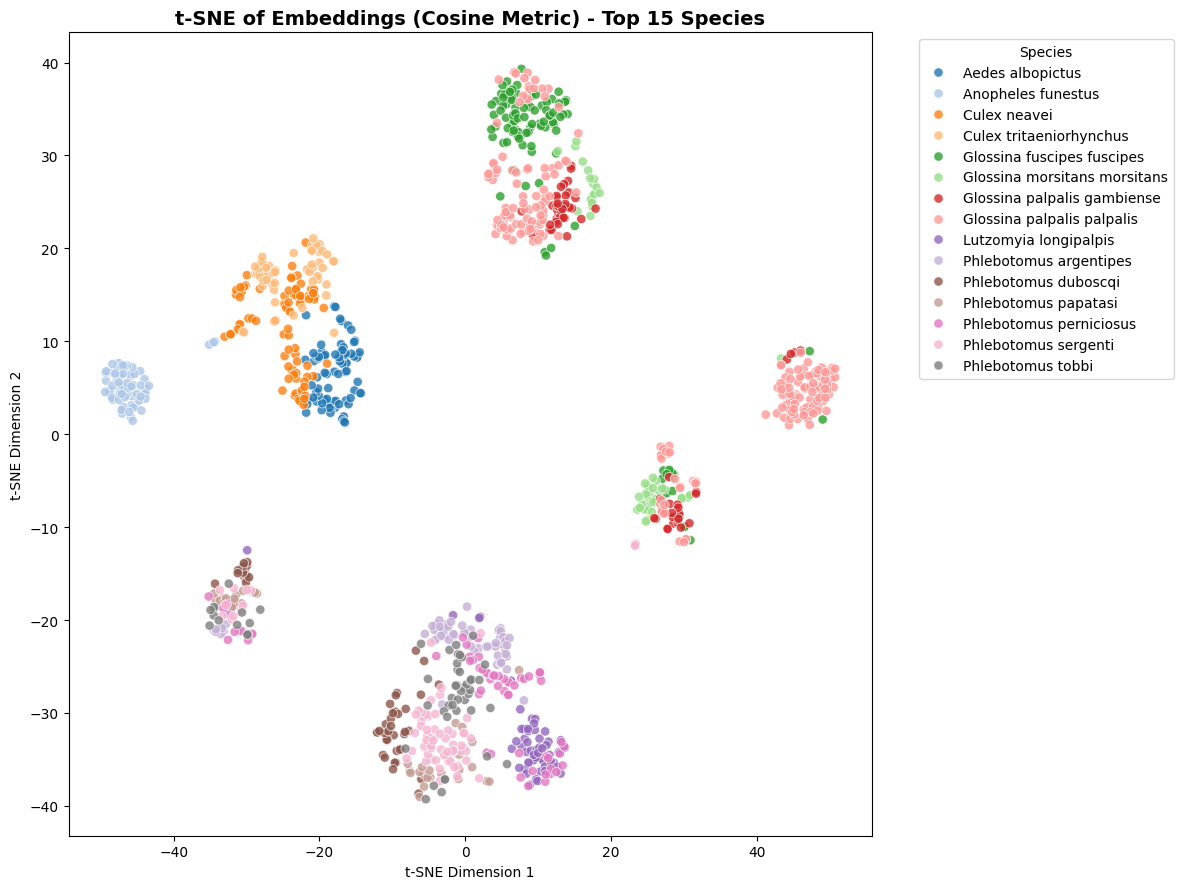

In [ ]:
# Graphical Representation of t-SNE (Top 15 most frequent species)

counts = np.bincount(y_labels)
top15_classes = np.argsort(counts)[-15:]

mask_top15 = np.isin(y_labels, top15_classes)
X_top15 = X_embed[mask_top15]
y_top15 = y_labels[mask_top15]

tsne = TSNE(n_components=2, metric='cosine', random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_top15)

top15_names = [class_names[c] for c in y_top15]

plt.figure(figsize=(12, 9))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=top15_names,
    palette=sns.color_palette("tab20", n_colors=15),
    legend='full',
    alpha=0.8,
    s=45
)
plt.title("t-SNE of Embeddings (Cosine Metric) - Top 15 Species", fontsize=14, weight='bold')
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Species")
plt.tight_layout()
plt.show()

In [ ]:
# EXPERIMENT 1: 5-Way 5-Shot Evaluation 

import numpy as np
import scipy.stats as stats
import torch

# Load best checkpoint
model.load_state_dict(torch.load('best_protonet_min2.pth', weights_only=True))
model.eval()

# Filter classes with at least 6 images (5 support + 1 query)
test_data_5s, test_classes_5s = load_filtered_dataset(test_path, min_samples=6)

N_WAY = 5
N_SUPPORT_5S = 5
N_QUERY = 1
n_test_episodes = 1000

test_acc_5s = []

with torch.no_grad():
    for _ in range(n_test_episodes):
        supp_t, qry_t, qry_lbls_t, n_w, n_s, n_q = sample_episode(
            test_data_5s, test_classes_5s,
            n_way=N_WAY, n_support=N_SUPPORT_5S, n_query=N_QUERY
        )
        _, t_acc = prototypical_loss(model, supp_t, qry_t, qry_lbls_t, n_w, n_s, n_q)
        test_acc_5s.append(t_acc.item())

mean_acc_5s = np.mean(test_acc_5s) * 100
std_err_5s = stats.sem(test_acc_5s) * 100
ci95_5s = 1.96 * std_err_5s

print(f"5-Way 5-Shot Accuracy: {mean_acc_5s:.2f}% +/- {ci95_5s:.2f}%")
print(f"Eligible Classes Evaluated: {len(test_classes_5s)}")

[test] Total classes: 129 | Eligible classes (>= 6 images): 46

Evaluating 5-way 5-shot over 1000 episodes...

5-Way 5-Shot Accuracy: 91.10% +/- 0.81%
Eligible Classes Evaluated: 46


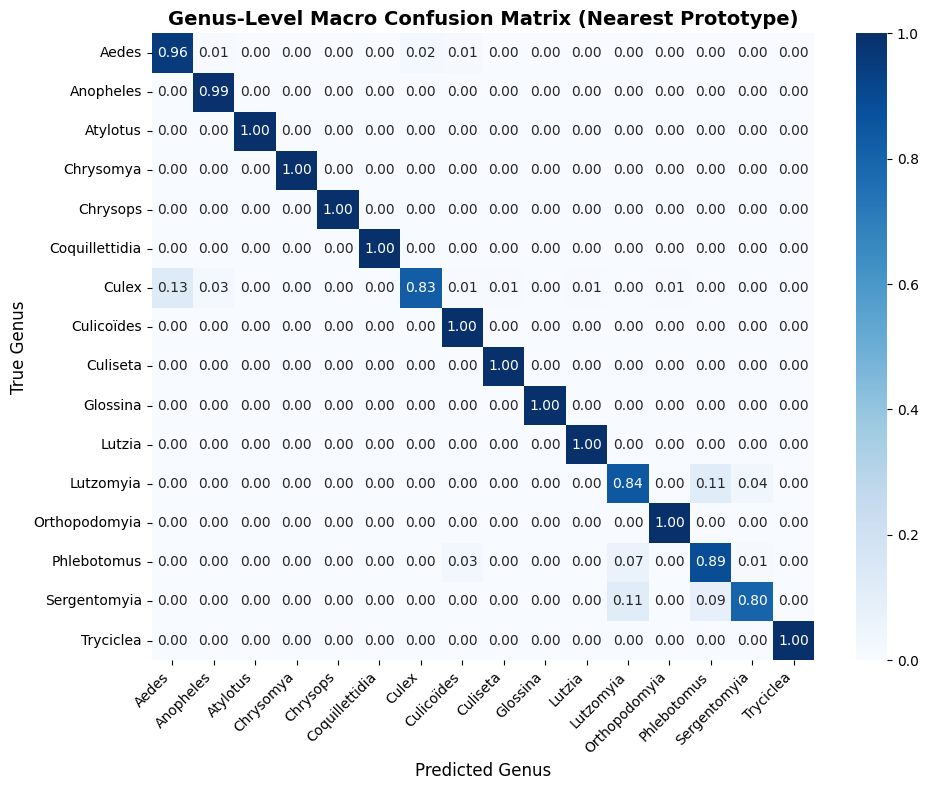


--- Per-Genus Macro Accuracy ---
Aedes          :  95.68% (162 samples)
Anopheles      :  99.27% (274 samples)
Atylotus       : 100.00% (2 samples)
Chrysomya      : 100.00% (2 samples)
Chrysops       : 100.00% (4 samples)
Coquillettidia : 100.00% (2 samples)
Culex          :  82.56% (195 samples)
Culicoïdes     : 100.00% (9 samples)
Culiseta       : 100.00% (2 samples)
Glossina       :  99.66% (580 samples)
Lutzia         : 100.00% (5 samples)
Lutzomyia      :  84.38% (96 samples)
Orthopodomyia  : 100.00% (6 samples)
Phlebotomus    :  88.78% (419 samples)
Sergentomyia   :  80.00% (35 samples)
Tryciclea      : 100.00% (4 samples)


In [ ]:
# EXPERIMENT: Genus-Level Confusion Matrix (Taxonomic Error Analysis)

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Extract genus name (first word of the scientific name) for each species
genus_names = sorted(list(set([name.split()[0] for name in class_names])))
genus_to_idx = {g: idx for idx, g in enumerate(genus_names)}

# Map ground-truth species labels and nearest-prototype predictions to genus indices
y_true_genus = np.array([genus_to_idx[class_names[idx].split()[0]] for idx in y_labels])
y_pred_genus = np.array([genus_to_idx[class_names[idx].split()[0]] for idx in proto_preds])

# Compute confusion matrix
cm_genus = confusion_matrix(y_true_genus, y_pred_genus)

# Normalize by row (recall per genus)
cm_genus_norm = cm_genus.astype('float') / cm_genus.sum(axis=1)[:, np.newaxis]

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_genus_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=genus_names,
    yticklabels=genus_names,
    cbar=True
)
plt.title('Genus-Level Macro Confusion Matrix (Nearest Prototype)', fontsize=14, weight='bold')
plt.xlabel('Predicted Genus', fontsize=12)
plt.ylabel('True Genus', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print per-genus accuracy
print("\n--- Per-Genus Macro Accuracy ---")
for idx, genus in enumerate(genus_names):
    acc = cm_genus_norm[idx, idx] * 100
    total_samples = np.sum(y_true_genus == idx)
    print(f"{genus:<15}: {acc:6.2f}% ({total_samples} samples)")

In [ ]:
# EXPERIMENT: Linear Probe Benchmark on Frozen Conv-4 Features

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Extracting train set embeddings for linear probing...")
# Extract embeddings for the training split using the trained encoder
X_train_emb, y_train_emb, train_class_names = extract_all_embeddings(model, train_data, transform)

# Find common classes between train and test to ensure a fair linear probe
common_classes = sorted(list(set(train_class_names).intersection(set(class_names))))
class_to_probe_idx = {cls: idx for idx, cls in enumerate(common_classes)}

# Filter train samples belonging to common classes
train_mask = np.isin([train_class_names[i] for i in y_train_emb], common_classes)
X_train_probe = X_train_emb[train_mask]
y_train_probe = np.array([class_to_probe_idx[train_class_names[i]] for i in y_train_emb[train_mask]])

# Filter test samples belonging to common classes
test_mask = np.isin([class_names[i] for i in y_labels], common_classes)
X_test_probe = X_embed[test_mask]
y_test_probe = np.array([class_to_probe_idx[class_names[i]] for i in y_labels[test_mask]])

# Train Linear Logistic Regression (Linear Probe)
clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
clf.fit(X_train_probe, y_train_probe)

# Predict on test embeddings
y_pred_probe = clf.predict(X_test_probe)
probe_acc = accuracy_score(y_test_probe, y_pred_probe) * 100

print(f"Linear Probe Accuracy: {probe_acc:.2f}%")
print(f"Common Classes Evaluated: {len(common_classes)}")

Extracting train set embeddings for linear probing...


Extracting embeddings: 100%|██████████| 118/118 [00:04<00:00, 24.38it/s]



Linear Probe Accuracy: 33.78%
Common Classes Evaluated: 107
